In [1]:
import os
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

In [11]:
import tensorflow as tf
import numpy as np
import random
import pandas as pd
from PIL import Image
import seaborn as sns
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D,Dense,Dropout,BatchNormalization
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from data.data import load_dataset
import evaluate


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [4]:
SEED = 42

random.seed(SEED)
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [4]:
X, y, X_test, y_test  = load_dataset(model = 'resnet50')  
X , X_test = resnet_preprocess(X) , resnet_preprocess(X_test)   

Loading cached dataset from data/dataset_rgb.npz...


In [4]:
print(f'X shape:{X.shape}, y shape:{y.shape}, X_test shape:{X_test.shape}')

X shape:(5600, 224, 224, 3), y shape:(5600,), X_test shape:(1600, 224, 224, 3)


In [5]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, y_train.shape, X_val.shape, y_val.shape

((4480, 224, 224, 3), (4480,), (1120, 224, 224, 3), (1120,))

In [8]:
base_res = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
base_res.trainable = False

I0000 00:00:1785001148.814339   21933 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3410 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [9]:
x = GlobalAveragePooling2D()(base_res.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
out = Dense(4, activation='softmax')(x)

resnet50 = Model(inputs=base_res.input, outputs=out)

In [10]:
resnet50.compile(
    optimizer = Adam(learning_rate=1e-4),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)


In [12]:
def data_generator(X, y, batch_size):
    n = len(X)
    while True:
        idx = np.random.permutation(n)
        for i in range(0, n, batch_size):
            batch_idx = idx[i:i+batch_size]
            yield X[batch_idx], y[batch_idx]

train_ds = tf.data.Dataset.from_generator(
    lambda: data_generator(X_train, y_train, batch_size=8),
    output_signature=(
        tf.TensorSpec(shape=(None, *X_train.shape[1:]), dtype=tf.float32),
        tf.TensorSpec(shape=(None, *y_train.shape[1:]), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_generator(
    lambda: data_generator(X_val, y_val, batch_size=8),
    output_signature=(
        tf.TensorSpec(shape=(None, *X_val.shape[1:]), dtype=tf.float32),
        tf.TensorSpec(shape=(None, *y_val.shape[1:]), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

history = resnet50.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    steps_per_epoch=len(X_train)//8,
    validation_steps=len(X_val)//8
)

Epoch 1/10


/home/rynoko/projects/MRI-GPU/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1785001150.569320   21933 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1785001154.364680   22034 service.cc:153] XLA service 0x7327ec034ad0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785001154.364708   22034 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1785001154.478021   22034 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00

  7/560 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.2857 - loss: 1.7877 

I0000 00:00:1785001161.395928   22034 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


560/560 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.7663 - loss: 0.6125 - val_accuracy: 0.8687 - val_loss: 0.3437
Epoch 2/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.8750 - loss: 0.3372 - val_accuracy: 0.9027 - val_loss: 0.2694
Epoch 3/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9031 - loss: 0.2760 - val_accuracy: 0.9045 - val_loss: 0.2498
Epoch 4/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9194 - loss: 0.2302 - val_accuracy: 0.9241 - val_loss: 0.2091
Epoch 5/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9310 - loss: 0.1948 - val_accuracy: 0.9170 - val_loss: 0.2072
Epoch 6/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9411 - loss: 0.1695 - val_accuracy: 0.9214 - val_loss: 0.1902
Epoch 7/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.9487 - loss: 0.1534 - val_accuracy: 0.9152 - val_loss: 0.1988
Epoch 8/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.9540 - loss: 0.1352 - val_accurac

In [13]:
base_res.trainable = True
for layer in base_res.layers[:-20]:
    layer.trainable = False

frozen_layers = 0
for layer in base_res.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False
        frozen_layers += 1

resnet50.compile(
    optimizer=Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


train_ds = tf.data.Dataset.from_generator(
    lambda: data_generator(X_train, y_train, batch_size=8),
    output_signature=(
        tf.TensorSpec(shape=(None, *X_train.shape[1:]), dtype=tf.float32),
        tf.TensorSpec(shape=(None, *y_train.shape[1:]), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_generator(
    lambda: data_generator(X_val, y_val, batch_size=8),
    output_signature=(
        tf.TensorSpec(shape=(None, *X_val.shape[1:]), dtype=tf.float32),
        tf.TensorSpec(shape=(None, *y_val.shape[1:]), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

history_1 = resnet50.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    steps_per_epoch=len(X_train) // 8,
    validation_steps=len(X_val) // 8,
    callbacks=[early_stop]
)

# Evaluate the same way — don't pass raw arrays here either
test_ds = tf.data.Dataset.from_generator(
    lambda: data_generator(X_test, y_test, batch_size=8),
    output_signature=(
        tf.TensorSpec(shape=(None, *X_test.shape[1:]), dtype=tf.float32),
        tf.TensorSpec(shape=(None, *y_test.shape[1:]), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

test_loss, test_acc = resnet50.evaluate(X_test, y_test, steps=len(X_test) // 8)

Epoch 1/15


I0000 00:00:1785001302.376845   22037 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_52299__.182


560/560 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.9721 - loss: 0.0897 - val_accuracy: 0.9375 - val_loss: 0.1527
Epoch 2/15
560/560 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - accuracy: 0.9886 - loss: 0.0421 - val_accuracy: 0.9509 - val_loss: 0.1212
Epoch 3/15
560/560 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.9929 - loss: 0.0270 - val_accuracy: 0.9509 - val_loss: 0.1394
Epoch 4/15
560/560 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - accuracy: 0.9955 - loss: 0.0174 - val_accuracy: 0.9571 - val_loss: 0.1337


W0000 00:00:1785001375.536297   21933 cpu_allocator_impl.cc:82] Allocation of 963379200 exceeds 10% of free system memory.
W0000 00:00:1785001376.974691   21933 cpu_allocator_impl.cc:82] Allocation of 963379200 exceeds 10% of free system memory.


200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9125 - loss: 0.4710


In [14]:
print(f'Accuracy: {test_acc:.2f}, Loss: {test_loss:.2f}')

Accuracy: 0.91, Loss: 0.47


In [15]:
CLASS_NAMES = ["notumor", "glioma", "meningioma", "pituitary"]

W0000 00:00:1785001385.361244   21933 cpu_allocator_impl.cc:82] Allocation of 963379200 exceeds 10% of free system memory.
W0000 00:00:1785001386.247973   21933 cpu_allocator_impl.cc:82] Allocation of 963379200 exceeds 10% of free system memory.


50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step
Classification Report:
               precision    recall  f1-score   support

     notumor     0.9344    0.9975    0.9649       400
      glioma     0.9797    0.7225    0.8317       400
  meningioma     0.8034    0.9500    0.8706       400
   pituitary     0.9679    0.9800    0.9739       400

    accuracy                         0.9125      1600
   macro avg     0.9213    0.9125    0.9103      1600
weighted avg     0.9213    0.9125    0.9103      1600



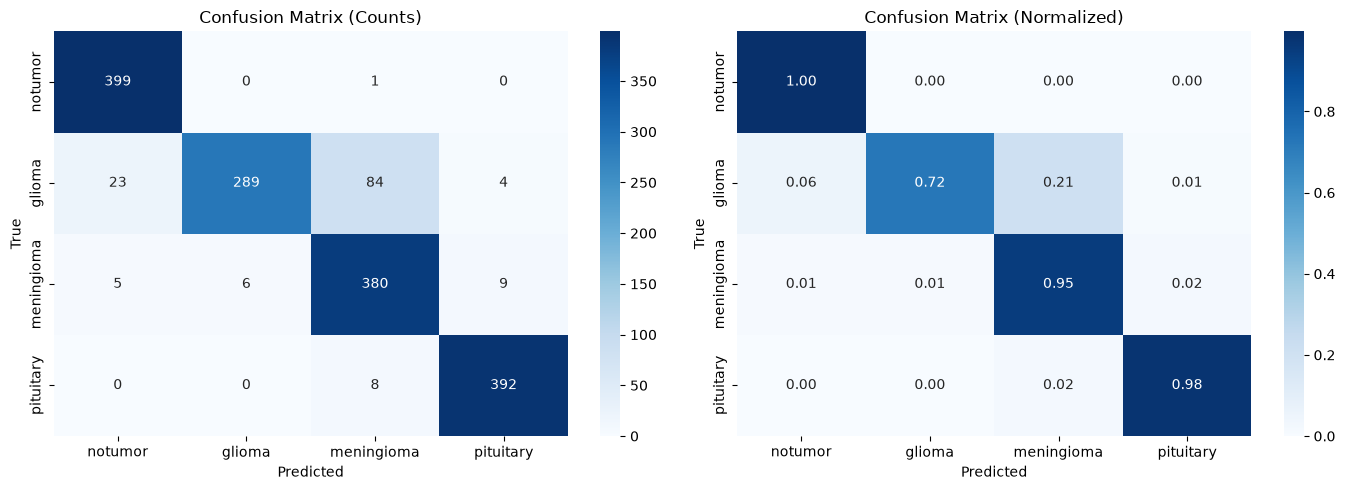

Macro-averaged AUC (OvR): 0.9799


W0000 00:00:1785001400.010934   21933 cpu_allocator_impl.cc:82] Allocation of 674365440 exceeds 10% of free system memory.


35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step
notumor - val precision: 0.9819, test precision: 0.9344
glioma - val precision: 0.9709, test precision: 0.9797
meningioma - val precision: 0.8920, test precision: 0.8034
pituitary - val precision: 0.9609, test precision: 0.9679


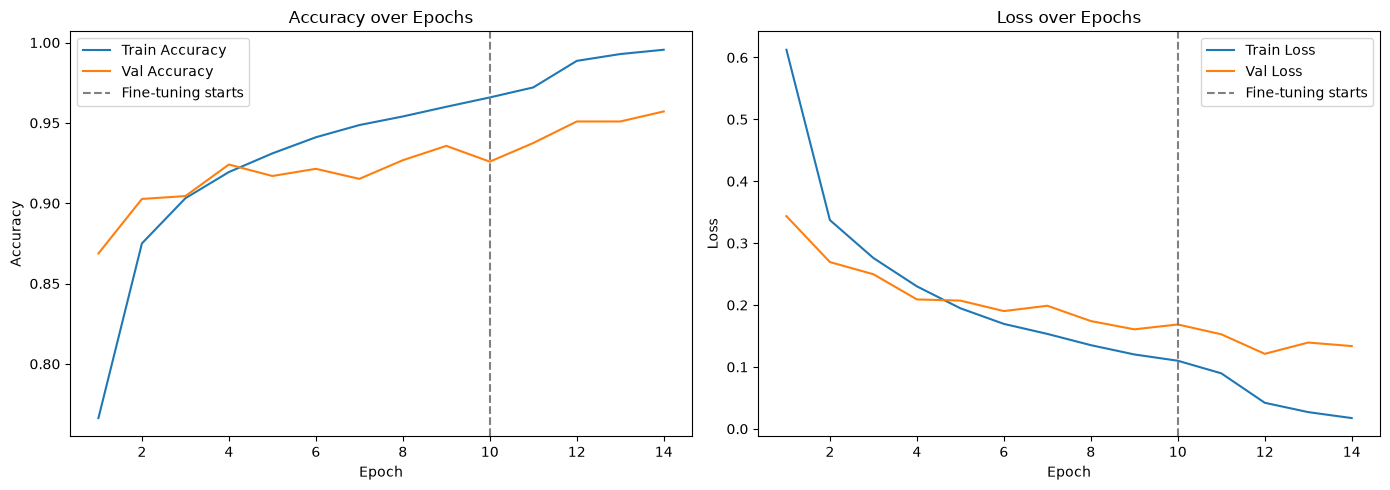

In [ ]:
results = evaluate.evaluate_model(resnet50, X_test, y_test, class_names=CLASS_NAMES, save_prefix="resnet50")
evaluate.evaluate_per_class(resnet50,X_val,X_test, y_val, y_test, CLASS_NAMES)
evaluate.plot_training_curves(history, history_1, save_prefix="resnet50")

resnet50.save("models/resnet50_mri_tumor.keras")

In [2]:
from keras.models import load_model
model = load_model('models/resnet50_mri_tumor.keras')

I0000 00:00:1786476670.643590   31337 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 941 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


False predictions made in Test set:



W0000 00:00:1785008780.782804    4843 cpu_allocator_impl.cc:82] Allocation of 963379200 exceeds 10% of free system memory.
W0000 00:00:1785008781.889485    4843 cpu_allocator_impl.cc:82] Allocation of 963379200 exceeds 10% of free system memory.


50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step


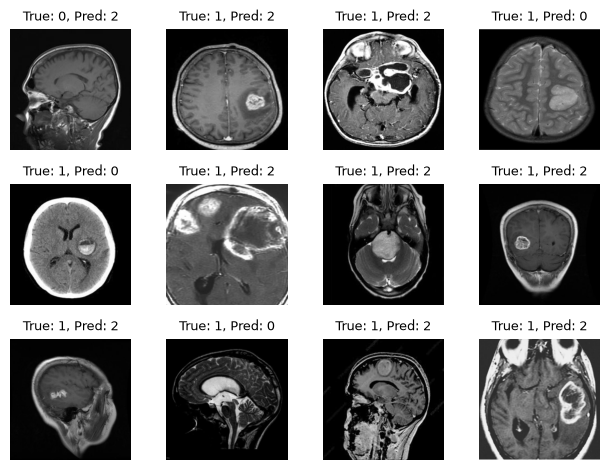


False predictions made in Validation set:

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step


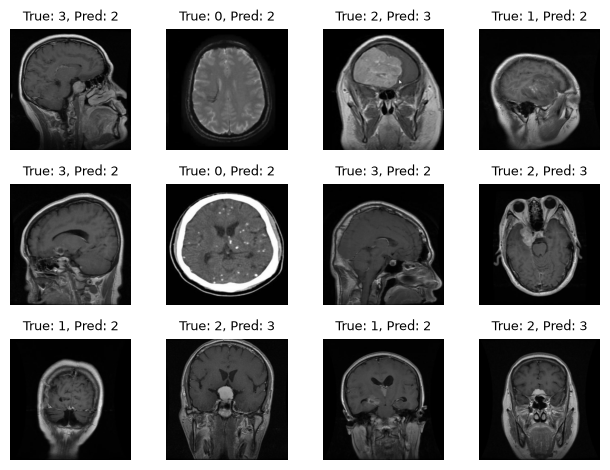

In [7]:
print('False predictions made in Test set:\n')
evaluate.plot_false_preds(model,X_test,y_test,'resnet50')

print('\nFalse predictions made in Validation set:\n')
evaluate.plot_false_preds(model,X_val,y_val,'resnet50')

I0000 00:00:1785008671.622252    4843 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
W0000 00:00:1785008676.470186    4843 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.
I0000 00:00:1785008676.472113    4843 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3808 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1785008682.956869    5108 service.cc:153] XLA service 0x7b8bcc0a4ba0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785008682.956897    5108 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 40

[resnet50_mri_tumor] 140 wrong predictions out of 1600 (showing first 12)


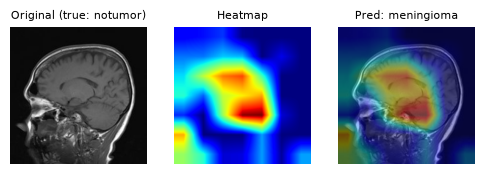

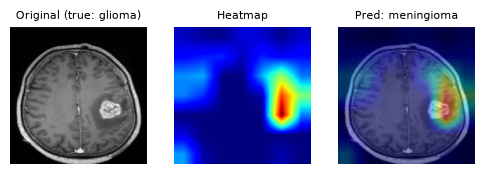

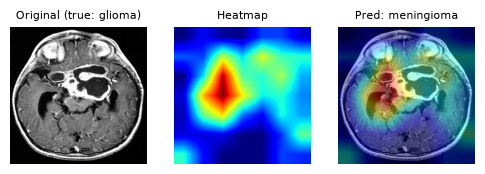

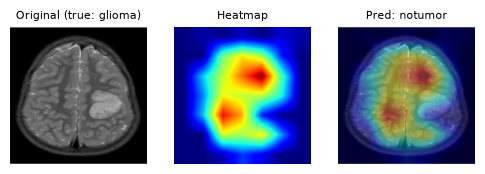

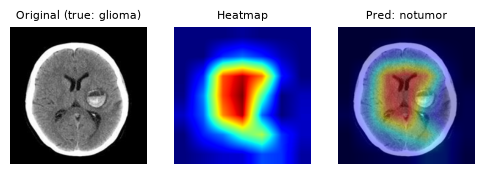

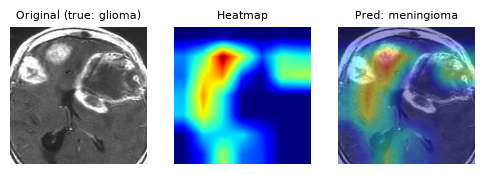

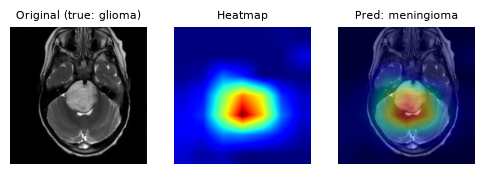

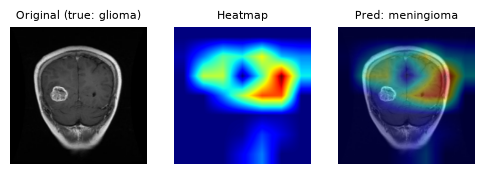

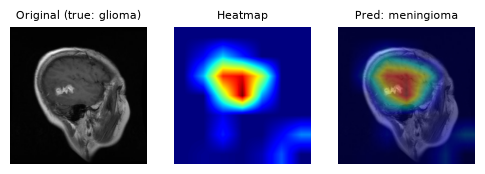

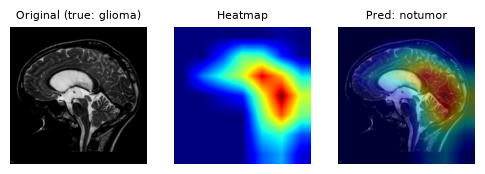

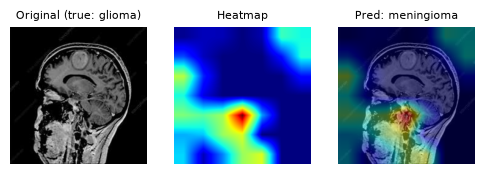

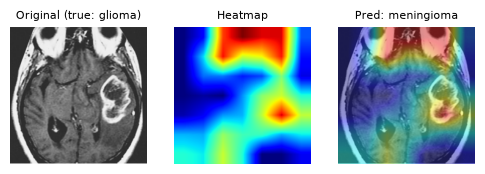

In [ ]:
from gradcam import get_models, prep_grad_model, run_for_model,DATA_FILES,PREPROCESS_FNS,get_wrong_prediction_losses

models = get_models()
gradCam_models = {name: prep_grad_model(obj, name) for name, obj in models.items()}
run_for_model("resnet50_mri_tumor", models, gradCam_models,max_examples=12)